In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Stock_Price_Data_[3921] (1).csv to Stock_Price_Data_[3921] (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('/content/drive/MyDrive/Artificial Intalligence/Stock_Price_Data_[3921] (1).csv')

print("Shape:", df.shape)           # rows x columns
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Shape: (9909, 7)

First 5 rows:
         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Basic Statistics:
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    3

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Total trading days:", len(df))

Date range: 1980-12-12 00:00:00 to 2020-04-01 00:00:00
Total trading days: 9909


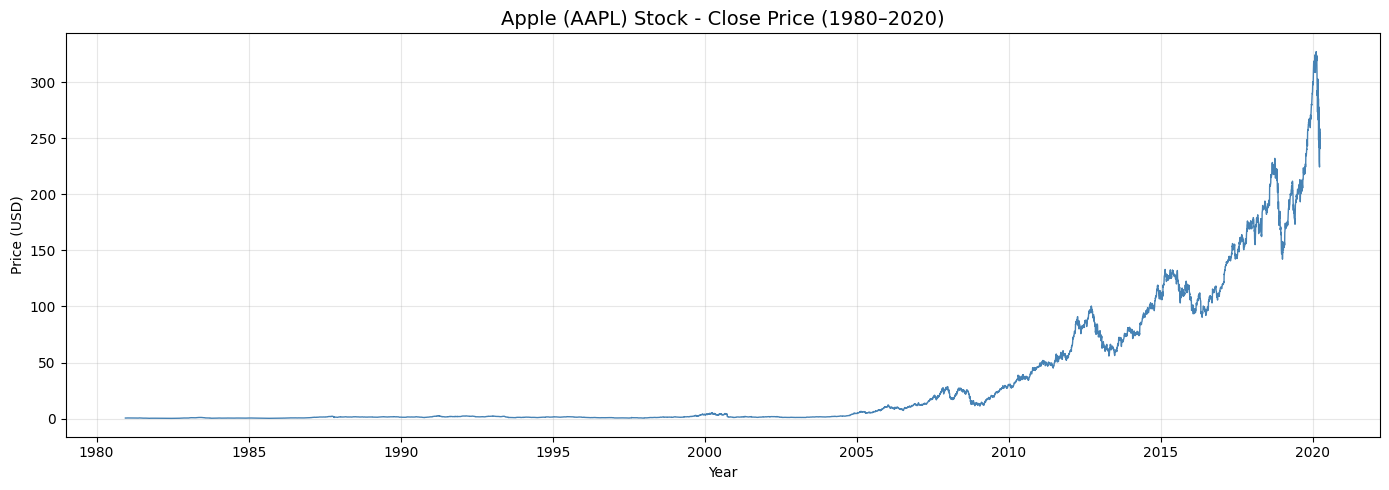

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
plt.title('Apple (AAPL) Stock - Close Price (1980–2020)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price_overview.png', dpi=150)
plt.show()

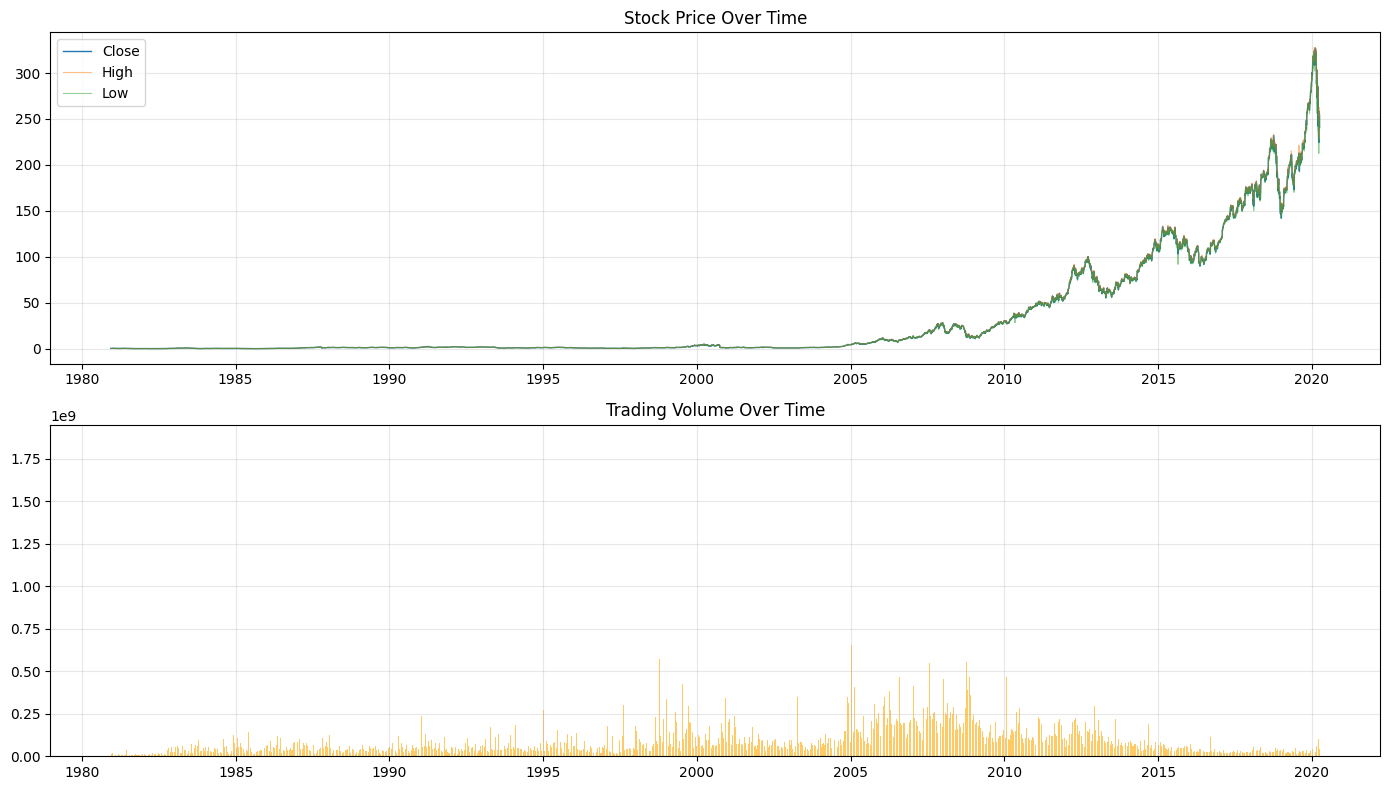

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price columns
axes[0].plot(df['Date'], df['Close'], label='Close', linewidth=1)
axes[0].plot(df['Date'], df['High'], label='High', alpha=0.5, linewidth=0.8)
axes[0].plot(df['Date'], df['Low'], label='Low', alpha=0.5, linewidth=0.8)
axes[0].set_title('Stock Price Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Volume'], color='orange', alpha=0.6, width=1)
axes[1].set_title('Trading Volume Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_full_overview.png', dpi=150)
plt.show()

In [ ]:
# Select Close price only
close_prices = df[['Date', 'Close']].copy()

print("Close price stats:")
print(close_prices['Close'].describe())

Close price stats:
count    9909.000000
mean       32.618030
std        58.471899
min         0.196429
25%         1.071429
50%         1.732143
75%        35.761429
max       327.200012
Name: Close, dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Extract just the values
data = close_prices['Close'].values.reshape(-1, 1)

# Scale to range 0-1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("Original price range: {:.2f} to {:.2f}".format(data.min(), data.max()))
print("Scaled range: {:.2f} to {:.2f}".format(scaled_data.min(), scaled_data.max()))
print("Scaled data shape:", scaled_data.shape)

Original price range: 0.20 to 327.20
Scaled range: 0.00 to 1.00
Scaled data shape: (9909, 1)


In [ ]:
# Each sample: 60 past days -> predict next day
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])  # 60 days input
    y.append(scaled_data[i, 0])                     # next day target

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 60)
print("y shape:", y.shape)  # (samples,)

X shape: (9849, 60)
y shape: (9849,)


In [ ]:
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 7879
Testing samples:  1970


In [ ]:
# LSTM/GRU expects: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("X_train final shape:", X_train.shape)  # (samples, 60, 1)
print("X_test final shape: ", X_test.shape)

X_train final shape: (7879, 60, 1)
X_test final shape:  (1970, 60, 1)


Train/test split date: 2012-06-04 00:00:00


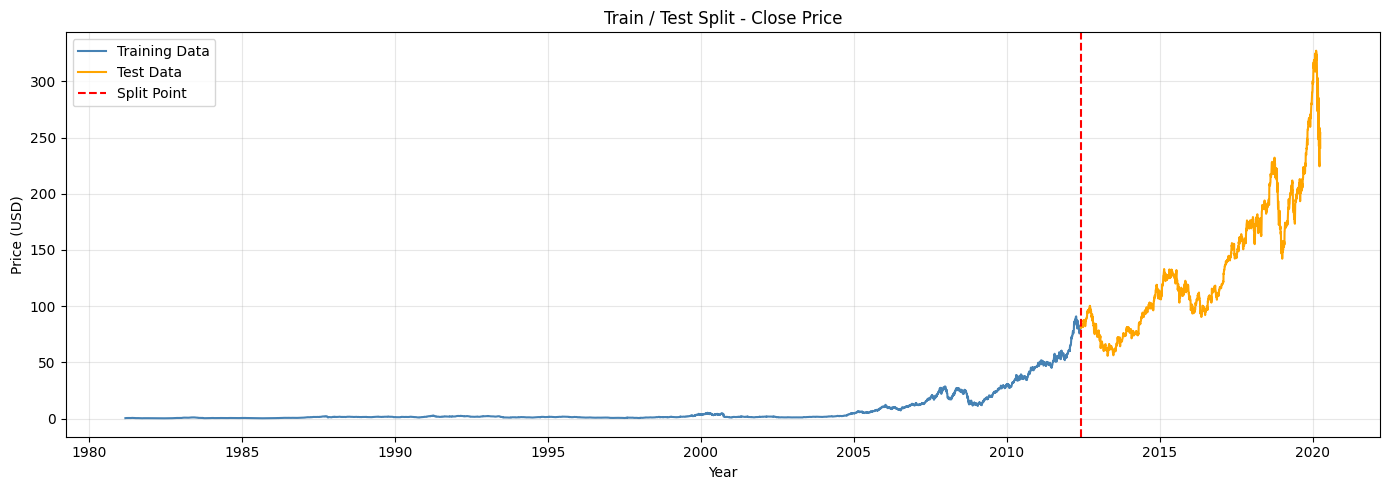

In [ ]:
# Find the date where test starts
split_date = close_prices['Date'].iloc[split + sequence_length]
print("Train/test split date:", split_date)

plt.figure(figsize=(14, 5))
plt.plot(close_prices['Date'].iloc[sequence_length:split + sequence_length],
         data[sequence_length:split + sequence_length],
         label='Training Data', color='steelblue')
plt.plot(close_prices['Date'].iloc[split + sequence_length:],
         data[split + sequence_length:],
         label='Test Data', color='orange')
plt.axvline(x=split_date, color='red', linestyle='--', label='Split Point')
plt.title('Train / Test Split - Close Price')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build LSTM model
lstm_model = Sequential([
    LSTM(units=100, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(units=100, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,751 (483.40 KB)

 Trainable params: 123,751 (483.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 3.5335e-06 - val_loss: 1.1930e-04
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 3.3136e-06 - val_loss: 9.5089e-05
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 3.1912e-06 - val_loss: 7.4688e-05
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 4.1878e-06 - val_loss: 2.3431e-05
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 3.2911e-06 - val_loss: 3.7862e-04
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 3.1076e-06 - val_loss: 3.8631e-05
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 2.8589e-06 - val_loss: 8.3848e-05
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 3.5425e-06 - val_loss: 1.1046e-04
Epoch 9/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 2.4910e-06 - val_loss: 4.9952e-05


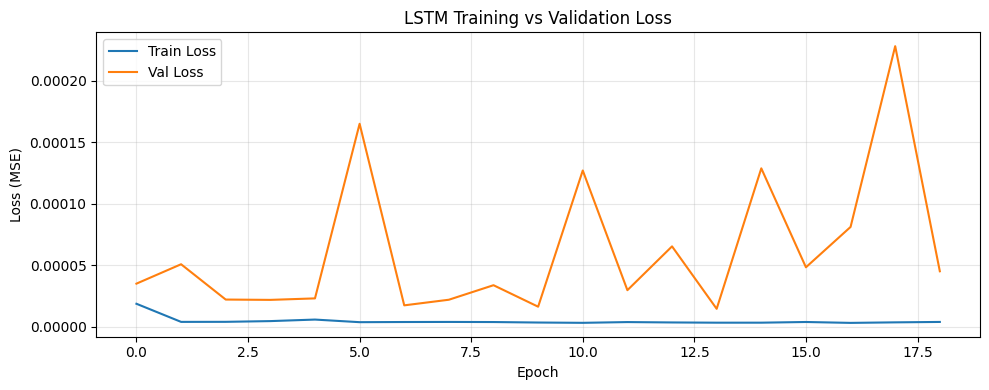

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()

In [ ]:
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


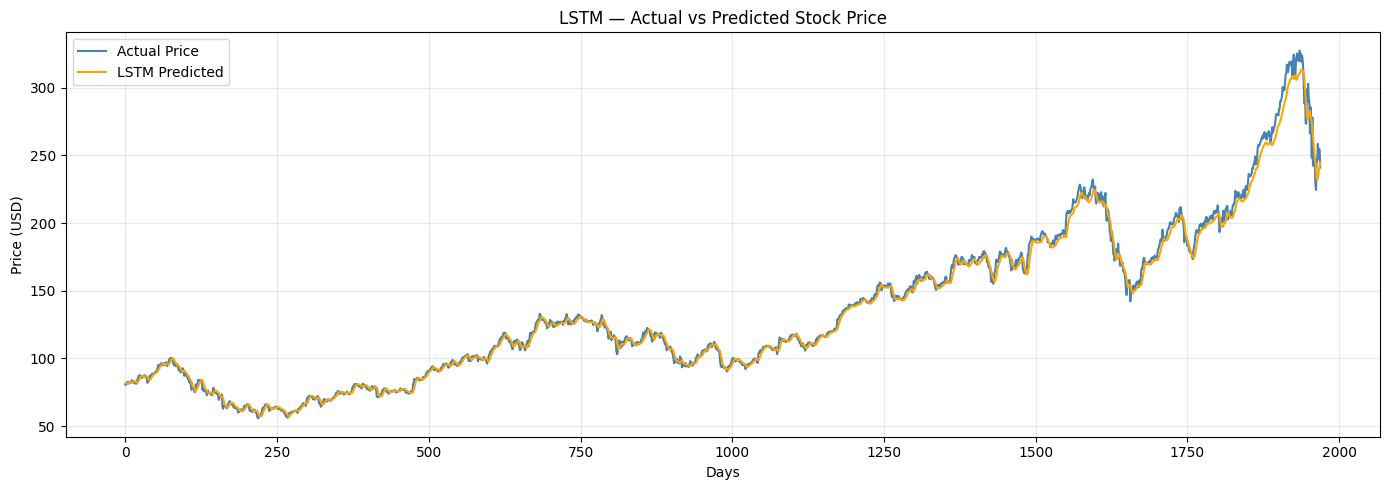

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Price', color='steelblue')
plt.plot(lstm_predictions, label='LSTM Predicted', color='orange')
plt.title('LSTM — Actual vs Predicted Stock Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lstm_mae  = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_r2   = r2_score(y_test_actual, lstm_predictions)

print("LSTM Results:")
print(f"  MAE  : {lstm_mae:.4f}")
print(f"  RMSE : {lstm_rmse:.4f}")
print(f"  R²   : {lstm_r2:.4f}")

LSTM Results:
  MAE  : 2.9415
  RMSE : 4.4266
  R²   : 0.9941


In [ ]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(units=100, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    GRU(units=100, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

gru_model.summary()

gru_model.compile(optimizer='adam', loss='mean_squared_error')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 100)            │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,051 (367.39 KB)

 Trainable params: 94,051 (367.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - loss: 3.3081e-05 - val_loss: 8.1379e-05
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 3.8448e-06 - val_loss: 1.3410e-05
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - loss: 3.3451e-06 - val_loss: 1.5265e-05
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - loss: 4.1261e-06 - val_loss: 3.5131e-04
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 3.4987e-06 - val_loss: 1.7359e-05
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 3.3826e-06 - val_loss: 1.1460e-05
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - loss: 2.8869e-06 - val_loss: 1.5923e-05
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 3.4969e-06 - val_loss: 1.9238e-05
Epoch 9/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 3.3528e-06 - val_loss: 3.8005e-05
Epoch 10/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 3.9831e-06 - val_loss: 2.5472e-04
Epoch 11/50
222/222 ━━━━━━━━━━━━━━━━━━━

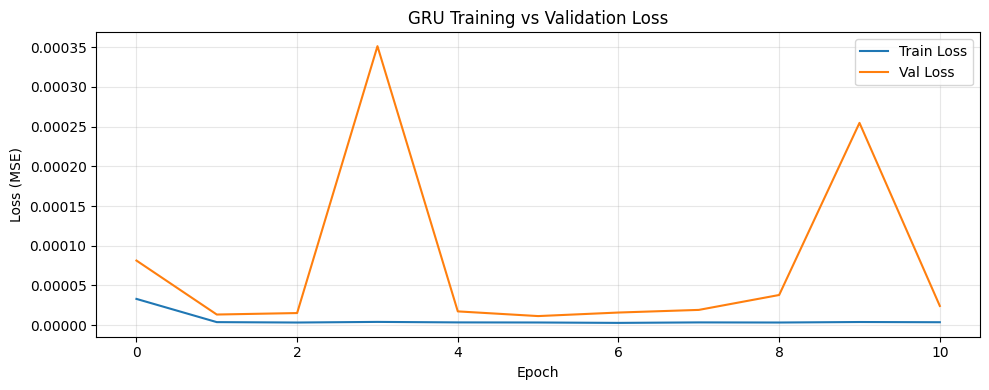

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['val_loss'], label='Val Loss')
plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gru_loss.png', dpi=150)
plt.show()

In [ ]:
gru_predictions = gru_model.predict(X_test)
gru_predictions = scaler.inverse_transform(gru_predictions)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


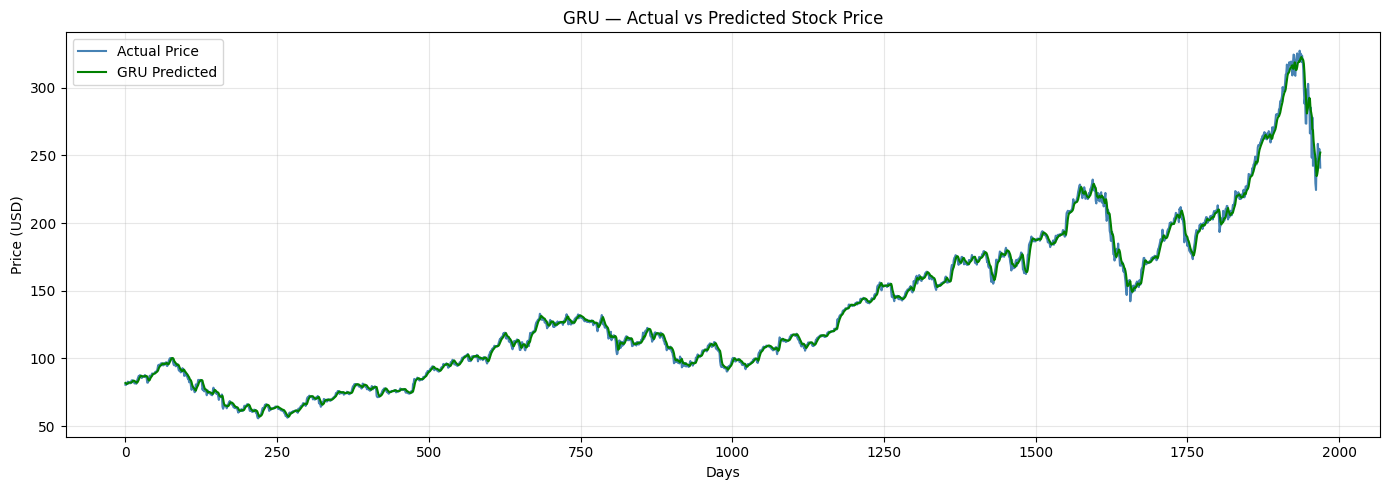

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Price', color='steelblue')
plt.plot(gru_predictions, label='GRU Predicted', color='green')
plt.title('GRU — Actual vs Predicted Stock Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gru_predictions.png', dpi=150)
plt.show()

In [ ]:
gru_mae  = mean_absolute_error(y_test_actual, gru_predictions)
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_predictions))
gru_r2   = r2_score(y_test_actual, gru_predictions)

print("GRU Results:")
print(f"  MAE  : {gru_mae:.4f}")
print(f"  RMSE : {gru_rmse:.4f}")
print(f"  R²   : {gru_r2:.4f}")

GRU Results:
  MAE  : 2.2037
  RMSE : 3.4288
  R²   : 0.9965


In [ ]:
print("=" * 40)
print(f"{'Metric':<10} {'LSTM':>10} {'GRU':>10}")
print("=" * 40)
print(f"{'MAE':<10} {lstm_mae:>10.4f} {gru_mae:>10.4f}")
print(f"{'RMSE':<10} {lstm_rmse:>10.4f} {gru_rmse:>10.4f}")
print(f"{'R²':<10} {lstm_r2:>10.4f} {gru_r2:>10.4f}")
print("=" * 40)

Metric           LSTM        GRU
MAE            2.9415     2.2037
RMSE           4.4266     3.4288
R²             0.9941     0.9965


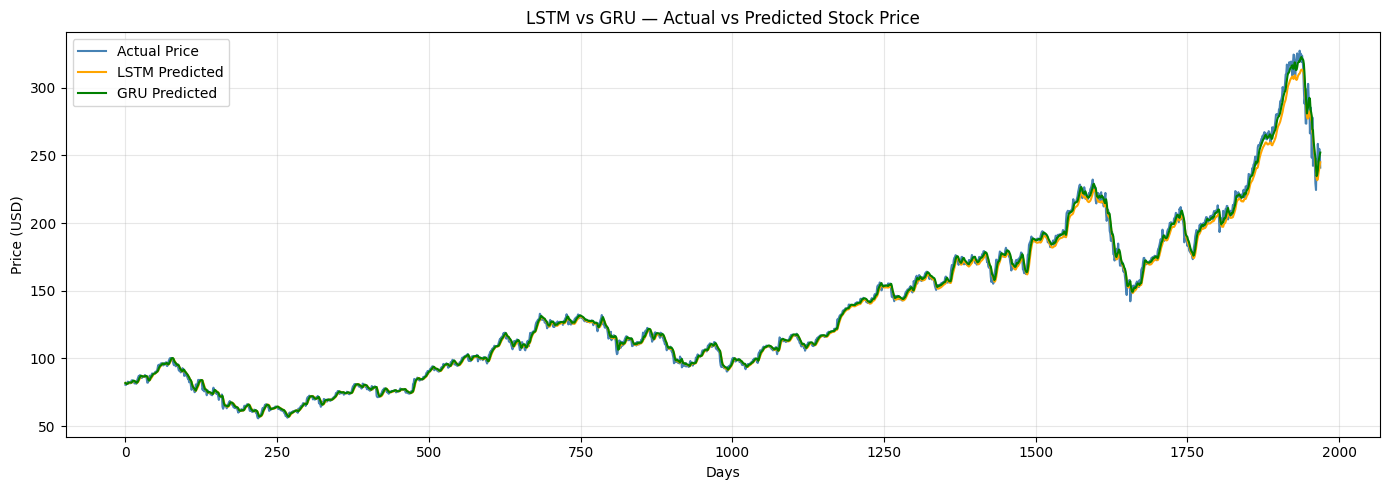

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Price', color='steelblue')
plt.plot(lstm_predictions, label='LSTM Predicted', color='orange')
plt.plot(gru_predictions, label='GRU Predicted', color='green')
plt.title('LSTM vs GRU — Actual vs Predicted Stock Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_vs_gru.png', dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

configs = [
    {'units': 100, 'dropout': 0.2, 'batch_size': 32},  # Config 1 - Original
    {'units': 50,  'dropout': 0.3, 'batch_size': 64},  # Config 2 - Lighter
    {'units': 150, 'dropout': 0.1, 'batch_size': 16},  # Config 3 - Heavier
]

results = []

for i, cfg in enumerate(configs):
    print(f"\n{'='*50}")
    print(f"Config {i+1}: units={cfg['units']}, dropout={cfg['dropout']}, batch={cfg['batch_size']}")
    print('='*50)

    # --- LSTM ---
    lstm = Sequential([
        LSTM(cfg['units'], return_sequences=True, input_shape=(60, 1)),
        Dropout(cfg['dropout']),
        LSTM(cfg['units'], return_sequences=False),
        Dropout(cfg['dropout']),
        Dense(25),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mean_squared_error')
    lstm.fit(X_train, y_train, epochs=50, batch_size=cfg['batch_size'],
             validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
             verbose=0)

    lstm_pred = scaler.inverse_transform(lstm.predict(X_test))
    lstm_mae  = mean_absolute_error(y_test_actual, lstm_pred)
    lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
    lstm_r2   = r2_score(y_test_actual, lstm_pred)

    # --- GRU ---
    gru = Sequential([
        GRU(cfg['units'], return_sequences=True, input_shape=(60, 1)),
        Dropout(cfg['dropout']),
        GRU(cfg['units'], return_sequences=False),
        Dropout(cfg['dropout']),
        Dense(25),
        Dense(1)
    ])
    gru.compile(optimizer='adam', loss='mean_squared_error')
    gru.fit(X_train, y_train, epochs=50, batch_size=cfg['batch_size'],
            validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
            verbose=0)

    gru_pred = scaler.inverse_transform(gru.predict(X_test))
    gru_mae  = mean_absolute_error(y_test_actual, gru_pred)
    gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_pred))
    gru_r2   = r2_score(y_test_actual, gru_pred)

    results.append({
        'Config': f"Config {i+1}",
        'Units': cfg['units'], 'Dropout': cfg['dropout'], 'Batch': cfg['batch_size'],
        'LSTM_MAE': lstm_mae, 'LSTM_RMSE': lstm_rmse, 'LSTM_R2': lstm_r2,
        'GRU_MAE':  gru_mae,  'GRU_RMSE':  gru_rmse,  'GRU_R2':  gru_r2
    })

    print(f"LSTM → MAE: {lstm_mae:.4f} | RMSE: {lstm_rmse:.4f} | R²: {lstm_r2:.4f}")
    print(f"GRU  → MAE: {gru_mae:.4f} | RMSE: {gru_rmse:.4f} | R²: {gru_r2:.4f}")


Config 1: units=100, dropout=0.2, batch=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
LSTM → MAE: 2.9966 | RMSE: 4.5178 | R²: 0.9939
GRU  → MAE: 2.0913 | RMSE: 3.2956 | R²: 0.9967

Config 2: units=50, dropout=0.3, batch=64


...

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
LSTM → MAE: 5.1616 | RMSE: 7.4133 | R²: 0.9835
GRU  → MAE: 2.7524 | RMSE: 4.1272 | R²: 0.9949

Config 3: units=150, dropout=0.1, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
LSTM → MAE: 2.1549 | RMSE: 3.3626 | R²: 0.9966
GRU  → MAE: 2.2139 | RMSE: 3.5426 | R²: 0.9962


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
print("\n LSTM Results Across Configs:")
print(results_df[['Config','Units','Dropout','Batch','LSTM_MAE','LSTM_RMSE','LSTM_R2']].to_string(index=False))

print("\n GRU Results Across Configs:")
print(results_df[['Config','Units','Dropout','Batch','GRU_MAE','GRU_RMSE','GRU_R2']].to_string(index=False))


 LSTM Results Across Configs:
  Config  Units  Dropout  Batch  LSTM_MAE  LSTM_RMSE  LSTM_R2
Config 1    100      0.2     32  2.996567   4.517770 0.993881
Config 2     50      0.3     64  5.161647   7.413287 0.983524
Config 3    150      0.1     16  2.154933   3.362588 0.996610

 GRU Results Across Configs:
  Config  Units  Dropout  Batch  GRU_MAE  GRU_RMSE   GRU_R2
Config 1    100      0.2     32 2.091307  3.295617 0.996744
Config 2     50      0.3     64 2.752393  4.127190 0.994893
Config 3    150      0.1     16 2.213883  3.542592 0.996238


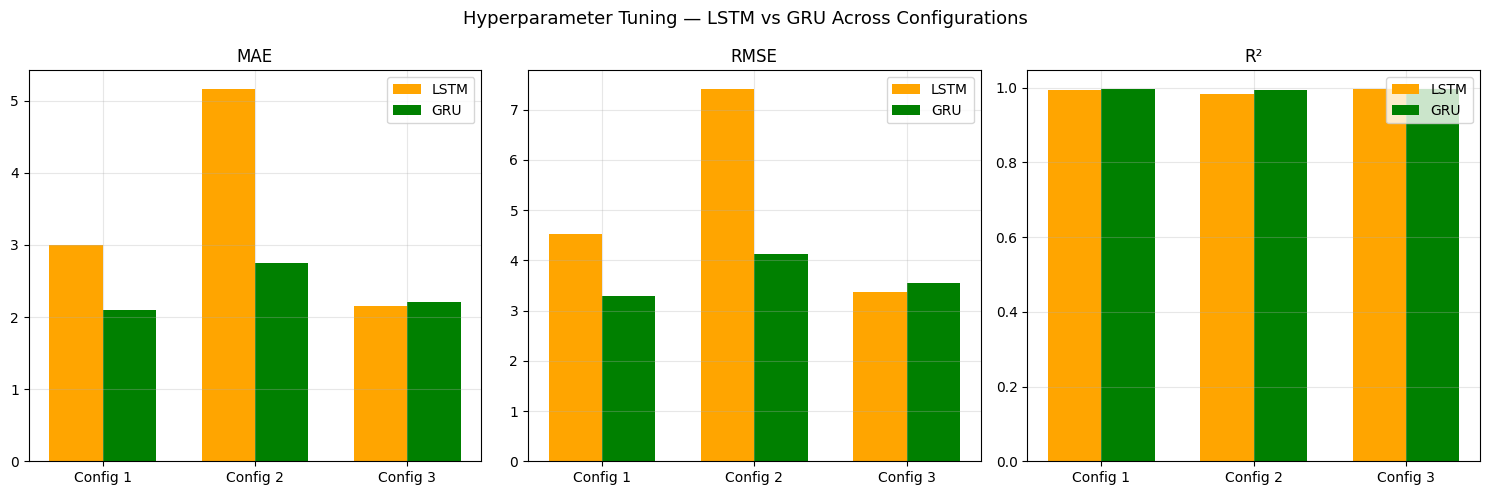

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs_labels = ['Config 1', 'Config 2', 'Config 3']
x = np.arange(len(configs_labels))
width = 0.35

for ax, metric, lstm_col, gru_col in zip(
    axes,
    ['MAE', 'RMSE', 'R²'],
    ['LSTM_MAE', 'LSTM_RMSE', 'LSTM_R2'],
    ['GRU_MAE',  'GRU_RMSE',  'GRU_R2']
):
    ax.bar(x - width/2, results_df[lstm_col], width, label='LSTM', color='orange')
    ax.bar(x + width/2, results_df[gru_col],  width, label='GRU',  color='green')
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(configs_labels)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Tuning — LSTM vs GRU Across Configurations', fontsize=13)
plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=150)
plt.show()

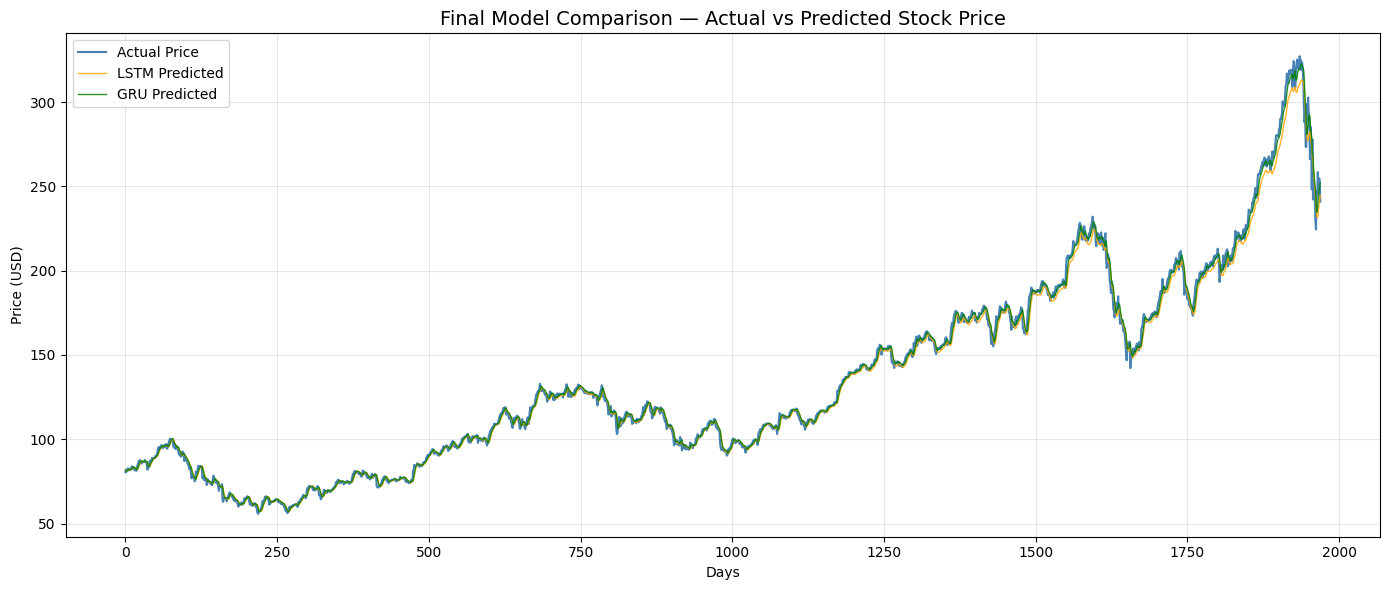

In [ ]:
# Plot best LSTM and GRU predictions from Phase 3 vs Actual
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Price', color='steelblue', linewidth=1.5)
plt.plot(lstm_predictions, label='LSTM Predicted', color='orange', linewidth=1, alpha=0.85)
plt.plot(gru_predictions, label='GRU Predicted', color='green', linewidth=1, alpha=0.85)
plt.title('Final Model Comparison — Actual vs Predicted Stock Price', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

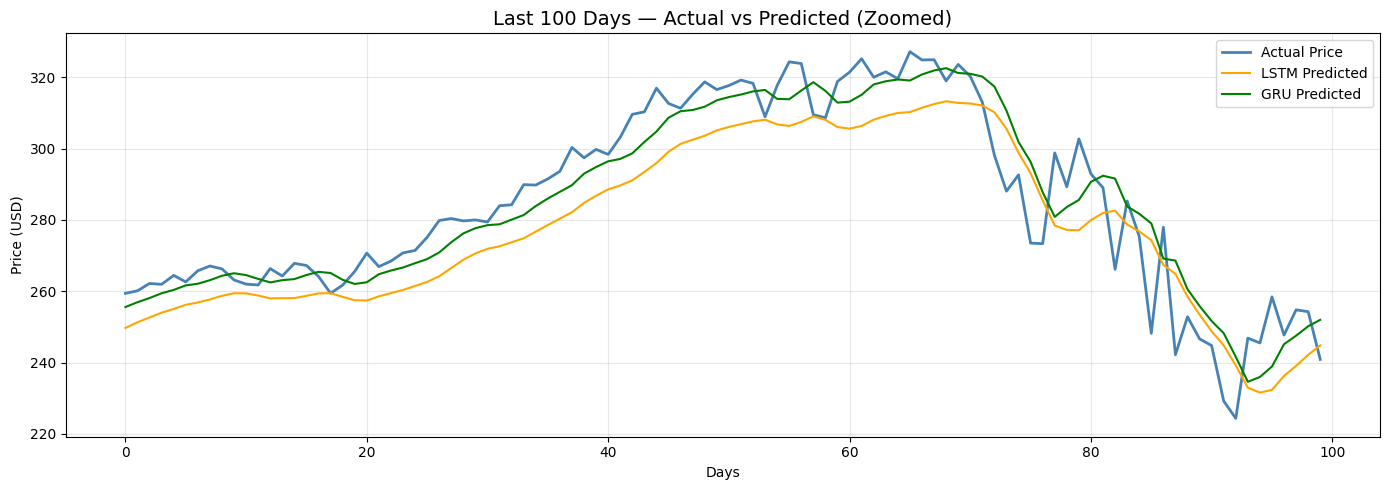

In [ ]:
# Zoom into last 100 days for clearer comparison
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[-100:], label='Actual Price', color='steelblue', linewidth=2)
plt.plot(lstm_predictions[-100:], label='LSTM Predicted', color='orange', linewidth=1.5)
plt.plot(gru_predictions[-100:], label='GRU Predicted', color='green', linewidth=1.5)
plt.title('Last 100 Days — Actual vs Predicted (Zoomed)', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zoomed_comparison.png', dpi=150)
plt.show()

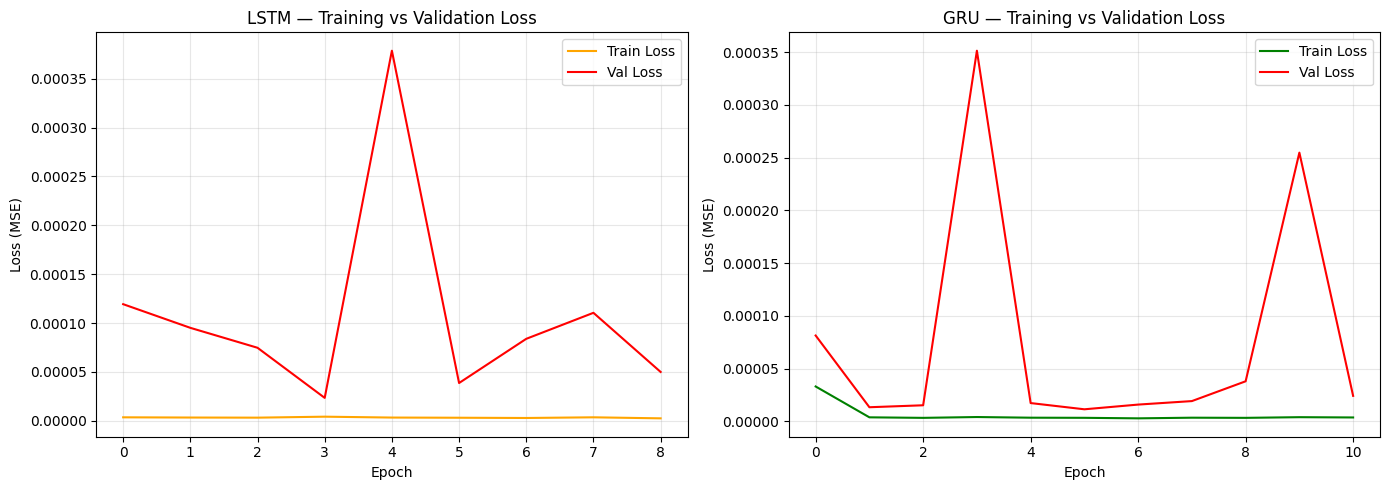

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'], label='Train Loss', color='orange')
axes[0].plot(lstm_history.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('LSTM — Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gru_history.history['loss'], label='Train Loss', color='green')
axes[1].plot(gru_history.history['val_loss'], label='Val Loss', color='red')
axes[1].set_title('GRU — Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves_comparison.png', dpi=150)
plt.show()

In [ ]:
print("=" * 45)
print(f"{'Metric':<12} {'LSTM':>10} {'GRU':>10}")
print("=" * 45)
print(f"{'MAE':<12} {lstm_mae:>10.4f} {gru_mae:>10.4f}")
print(f"{'RMSE':<12} {lstm_rmse:>10.4f} {gru_rmse:>10.4f}")
print(f"{'R²':<12} {lstm_r2:>10.4f} {gru_r2:>10.4f}")
print("=" * 45)

# Determine winner
if lstm_rmse < gru_rmse:
    print("\n LSTM performs better based on RMSE")
else:
    print("\n GRU performs better based on RMSE")

Metric             LSTM        GRU
MAE              2.1549     2.2139
RMSE             3.3626     3.5426
R²               0.9966     0.9962

 LSTM performs better based on RMSE


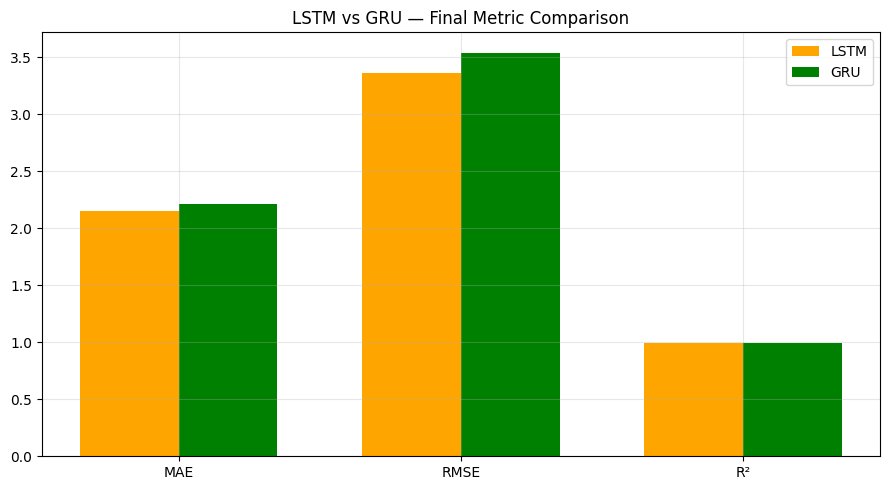

In [ ]:
metrics = ['MAE', 'RMSE', 'R²']
lstm_scores = [lstm_mae, lstm_rmse, lstm_r2]
gru_scores  = [gru_mae,  gru_rmse,  gru_r2]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lstm_scores, width, label='LSTM', color='orange')
ax.bar(x + width/2, gru_scores,  width, label='GRU',  color='green')
ax.set_title('LSTM vs GRU — Final Metric Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150)
plt.show()

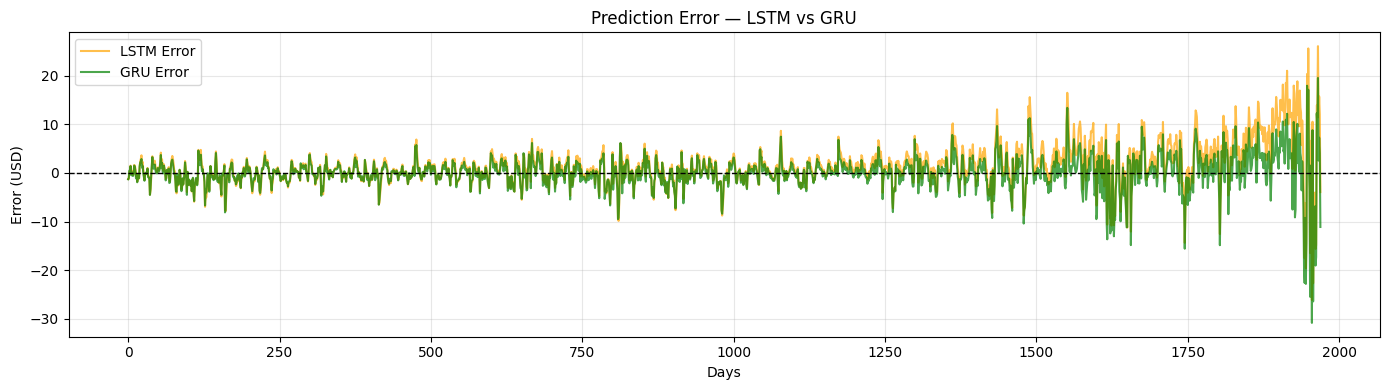

In [ ]:
lstm_errors = y_test_actual.flatten() - lstm_predictions.flatten()
gru_errors  = y_test_actual.flatten() - gru_predictions.flatten()

plt.figure(figsize=(14, 4))
plt.plot(lstm_errors, label='LSTM Error', color='orange', alpha=0.7)
plt.plot(gru_errors,  label='GRU Error',  color='green',  alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Error — LSTM vs GRU')
plt.xlabel('Days')
plt.ylabel('Error (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_errors.png', dpi=150)
plt.show()